# 04 — Evaluation

**Purpose.** Score the four trained conditions and answer the two research
questions.

| | |
|---|---|
| **Input**  | `models/*.keras`, `results/thresholds.json`, `data/processed/dev_cleaned.csv` |
| **Output** | result tables in `results/`, figures in `figures/` |
| **Next**   | the Streamlit UI in `app/` |

**Research questions**

* **RQ1** — to what extent does emoji handling affect performance?
  Measured as `ΔF1 = F1(with emoji) − F1(without emoji)`.
* **RQ2** — does that effect depend on the architecture and on the specific emotion?

Everything below is computed on the **development split**. The test split was
prepared but deliberately left unconsumed, so it remains a clean holdout — the
final section runs it only if you explicitly opt in.

In [ ]:
import os
from pathlib import Path

ON_KAGGLE = os.path.exists("/kaggle/working")

if ON_KAGGLE:
    PROJECT = Path("/kaggle/working")
    RAW_CANDIDATES = [Path("/kaggle/input")]
else:
    # notebooks/ lives one level below the project root
    PROJECT = Path.cwd()
    if PROJECT.name == "notebooks":
        PROJECT = PROJECT.parent
    RAW_CANDIDATES = [PROJECT / "data" / "raw"]

INTERIM   = PROJECT / "data" / "interim"
PROCESSED = PROJECT / "data" / "processed"
MODELS    = PROJECT / "models"
RESULTS   = PROJECT / "results"
FIGURES   = PROJECT / "figures"
for d in (INTERIM, PROCESSED, MODELS, RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

EMOTION_LABELS = [
    "anger", "anticipation", "disgust", "fear", "joy", "love",
    "optimism", "pessimism", "sadness", "surprise", "trust",
]
TRACKS = [
    ("no_emoji",   "text_no_emoji",   "Without Emoji"),
    ("with_emoji", "text_with_emoji", "With Emoji"),
]

print("project root :", PROJECT)
print("on kaggle    :", ON_KAGGLE)

project root : D:\assigments_7_students\krish
on kaggle    : False


In [ ]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
BLUE, RUST = "#3B6EA5", "#B3512F"

MODEL_LABEL = {"LSTM": "BiLSTM", "BERT": "Transformer"}
TRACK_LABEL = {"no_emoji": "Without Emoji", "with_emoji": "With Emoji"}

dev = pd.read_csv(PROCESSED / "dev_cleaned.csv")
y_true = dev[EMOTION_LABELS].values.astype(int)

thresholds = json.loads((RESULTS / "thresholds.json").read_text())
print("development rows:", len(dev))
print("thresholds:", thresholds)

development rows: 886
thresholds: {'LSTM_no_emoji': 0.55, 'LSTM_with_emoji': 0.55, 'BERT_no_emoji': 0.55, 'BERT_with_emoji': 0.55}


## 4.1 Score all four conditions

Models are loaded with `compile=False` — the custom training loss is irrelevant
to inference — and the sigmoid is applied here because the models emit raw
logits.

In [ ]:
probs, preds = {}, {}

for model_key in ("LSTM", "BERT"):
    for track, text_col, _ in TRACKS:
        path = MODELS / f"{model_key.lower()}_{track}.keras"
        if not path.exists():
            raise FileNotFoundError(f"{path} missing - run 03_model_train.ipynb first")

        model = tf.keras.models.load_model(str(path), compile=False)
        logits = model.predict(
            tf.constant(dev[text_col].astype(str).tolist(), dtype=tf.string),
            batch_size=64, verbose=0)
        p = tf.nn.sigmoid(logits).numpy()

        key = (model_key, track)
        probs[key] = p
        preds[key] = (p >= thresholds[f"{model_key}_{track}"]).astype(int)
        print(f"scored {MODEL_LABEL[model_key]:12s} {TRACK_LABEL[track]}")

scored BiLSTM       Without Emoji


scored BiLSTM       With Emoji


scored Transformer  Without Emoji


scored Transformer  With Emoji


## 4.2 Overall metrics

Plain accuracy is misleading here: roughly three quarters of all label decisions
are negative, so a model predicting nothing at all would still look accurate.
Micro-F1 is therefore the primary measure, with Macro-F1 alongside it — the gap
between the two reads out how unevenly performance is spread across the eleven
emotions.

In [ ]:
rows = []
for (model_key, track), y_pred in preds.items():
    rows.append({
        "Model": MODEL_LABEL[model_key],
        "Track": TRACK_LABEL[track],
        "Micro F1": round(f1_score(y_true, y_pred, average="micro", zero_division=0) * 100, 2),
        "Macro F1": round(f1_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "Label Accuracy": round((y_true == y_pred).mean() * 100, 2),
        "Subset Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision": round(precision_score(y_true, y_pred, average="micro", zero_division=0) * 100, 2),
        "Recall": round(recall_score(y_true, y_pred, average="micro", zero_division=0) * 100, 2),
        "Threshold": thresholds[f"{model_key}_{track}"],
    })

results_table = pd.DataFrame(rows)
results_table.to_csv(RESULTS / "results_table.csv", index=False)
display(results_table)

gap = (results_table["Micro F1"] - results_table["Macro F1"]).mean()
print(f"mean Micro-Macro gap: {gap:.2f} points "
      "-> performance is concentrated in the frequent emotions")

,Model,Track,Micro F1,Macro F1,Label Accuracy,Subset Accuracy,Precision,Recall,Threshold
0,BiLSTM,Without Emoji,53.63,47.86,74.02,5.53,44.38,67.75,0.55
1,BiLSTM,With Emoji,55.65,48.86,75.85,9.48,46.93,68.35,0.55
2,Transformer,Without Emoji,47.29,44.36,70.19,1.81,38.90,60.30,0.55
3,Transformer,With Emoji,51.00,47.30,72.63,3.39,42.29,64.23,0.55


mean Micro-Macro gap: 4.80 points -> performance is concentrated in the frequent emotions


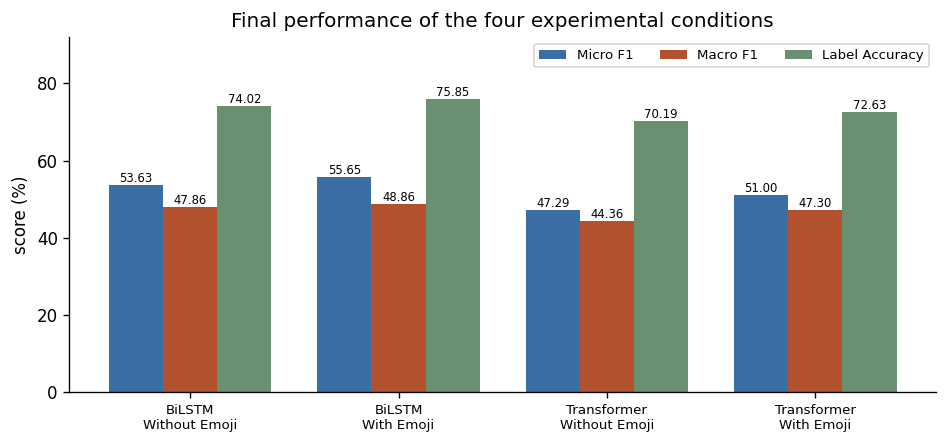

In [ ]:
x = np.arange(len(results_table))
w = 0.26
fig, ax = plt.subplots(figsize=(8, 3.8))
for off, col, colour in ((-w, "Micro F1", BLUE), (0, "Macro F1", RUST),
                         (w, "Label Accuracy", "#6B8F71")):
    bars = ax.bar(x + off, results_table[col], w, label=col, color=colour)
    ax.bar_label(bars, fmt="%.2f", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([f"{r.Model}\n{r.Track}" for r in results_table.itertuples()],
                   fontsize=8)
ax.set_ylabel("score (%)")
ax.set_ylim(0, 92)
ax.legend(fontsize=8, ncol=3)
ax.set_title("Final performance of the four experimental conditions")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "overall_performance.png")
plt.show()

## 4.3 RQ1 — the aggregate emoji effect

`ΔF1 = F1(with emoji) − F1(without emoji)`. A positive value means keeping emoji
as text helped; a negative value means removing them was better.

,Model,d_micro_f1,d_macro_f1,Direction
0,BiLSTM,2.03,0.99,emoji helps
1,Transformer,3.71,2.94,emoji helps


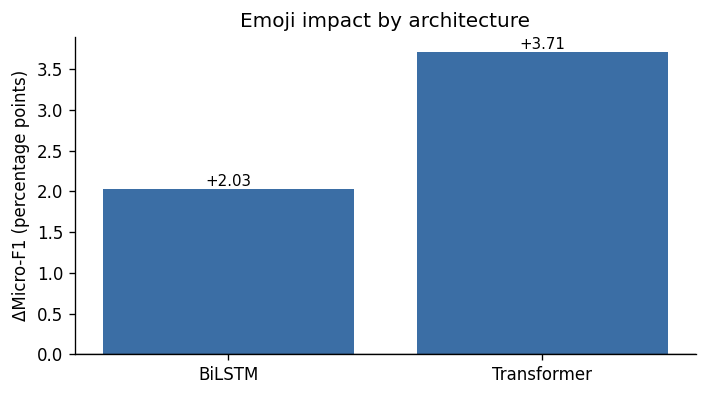

In [ ]:
def score(model_key, track, average):
    return f1_score(y_true, preds[(model_key, track)],
                    average=average, zero_division=0) * 100


impact = []
for model_key in ("LSTM", "BERT"):
    d_micro = score(model_key, "with_emoji", "micro") - score(model_key, "no_emoji", "micro")
    d_macro = score(model_key, "with_emoji", "macro") - score(model_key, "no_emoji", "macro")
    impact.append({"Model": MODEL_LABEL[model_key],
                   "d_micro_f1": round(d_micro, 2),
                   "d_macro_f1": round(d_macro, 2),
                   "Direction": "emoji helps" if d_micro > 0 else "emoji hurts"})

emoji_impact = pd.DataFrame(impact)
emoji_impact.to_csv(RESULTS / "emoji_impact.csv", index=False)
display(emoji_impact)

fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(emoji_impact["Model"], emoji_impact["d_micro_f1"],
              color=[BLUE if v > 0 else RUST for v in emoji_impact["d_micro_f1"]])
ax.bar_label(bars, fmt="%+.2f", fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("ΔMicro-F1 (percentage points)")
ax.set_title("Emoji impact by architecture")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "emoji_impact.png")
plt.show()

if len(set(np.sign(emoji_impact["d_micro_f1"]))) > 1:
    print("The two architectures move in OPPOSITE directions -> the effect is")
    print("architecture-dependent, so no single general claim is supported (RQ2).")

## 4.4 RQ2, part one — per-emotion effect

An aggregate figure can average a large gain on one label against a large loss on
another and report approximately nothing. Breaking ΔF1 down by label is what makes
the structure visible, and it is the study's most robust finding.

In [ ]:
per_class = {(m, t): f1_score(y_true, preds[(m, t)], average=None, zero_division=0) * 100
             for (m, t) in preds}

rows = []
for i, emo in enumerate(EMOTION_LABELS):
    d_lstm = per_class[("LSTM", "with_emoji")][i] - per_class[("LSTM", "no_emoji")][i]
    d_trf  = per_class[("BERT", "with_emoji")][i] - per_class[("BERT", "no_emoji")][i]
    rows.append({
        "Emotion": emo,
        "BiLSTM without": round(per_class[("LSTM", "no_emoji")][i], 1),
        "BiLSTM with":    round(per_class[("LSTM", "with_emoji")][i], 1),
        "d BiLSTM":       round(d_lstm, 2),
        "Transf. without": round(per_class[("BERT", "no_emoji")][i], 1),
        "Transf. with":    round(per_class[("BERT", "with_emoji")][i], 1),
        "d Transformer":   round(d_trf, 2),
        "Mean d":          round((d_lstm + d_trf) / 2, 2),
    })

per_emotion = pd.DataFrame(rows).sort_values("Mean d", ascending=False)
per_emotion.to_csv(RESULTS / "per_emotion_impact.csv", index=False)
display(per_emotion)

spread = per_emotion[["d BiLSTM", "d Transformer"]].values
print(f"per-emotion effect ranges from {spread.min():+.2f} to {spread.max():+.2f} "
      f"({spread.max() - spread.min():.1f} points of spread)")
print(f"aggregate effects were only {emoji_impact['d_micro_f1'].abs().max():.2f} points")
print("\n-> the aggregate figure is the near-cancellation of much larger,")
print("   opposing per-label movements, not a weak uniform trend.")

,Emotion,BiLSTM without,BiLSTM with,d BiLSTM,Transf. without,Transf. with,d Transformer,Mean d
8,sadness,54.6,58.0,3.35,44.8,56.6,11.80,7.58
3,fear,51.0,59.1,8.09,46.8,50.6,3.81,5.95
6,optimism,65.3,67.2,1.87,63.1,65.6,2.54,2.21
4,joy,75.4,78.3,2.94,72.9,73.7,0.84,1.89
5,love,50.6,50.5,-0.09,54.8,58.2,3.38,1.64
2,disgust,65.7,66.5,0.72,63.0,64.7,1.71,1.21
7,pessimism,31.4,31.4,-0.01,31.2,33.5,2.29,1.14
10,trust,17.3,17.0,-0.37,12.7,15.3,2.52,1.07
1,anticipation,31.3,27.2,-4.13,25.9,30.0,4.10,-0.01
0,anger,68.4,69.3,0.85,64.3,63.3,-0.96,-0.05


per-emotion effect ranges from -4.13 to +11.80 (15.9 points of spread)
aggregate effects were only 3.71 points

-> the aggregate figure is the near-cancellation of much larger,
   opposing per-label movements, not a weak uniform trend.


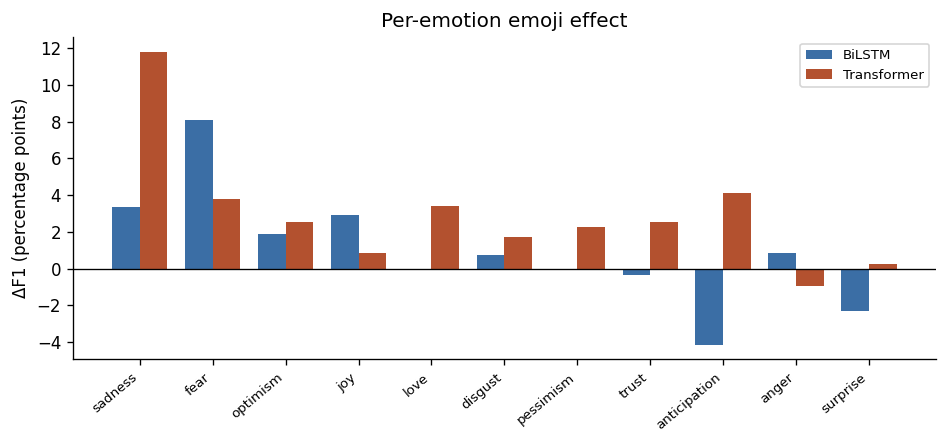

In [ ]:
order = per_emotion["Emotion"].tolist()
x = np.arange(len(order))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - w / 2, per_emotion["d BiLSTM"], w, label="BiLSTM", color=BLUE)
ax.bar(x + w / 2, per_emotion["d Transformer"], w, label="Transformer", color=RUST)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("ΔF1 (percentage points)")
ax.set_title("Per-emotion emoji effect")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "per_emotion_impact.png")
plt.show()

## 4.5 Confusion matrices

F1 hides *which* error is being made. Under a weighted loss with a low threshold,
rare emotions are typically over-predicted — many false positives bought in
exchange for recall — and only the raw counts show that.

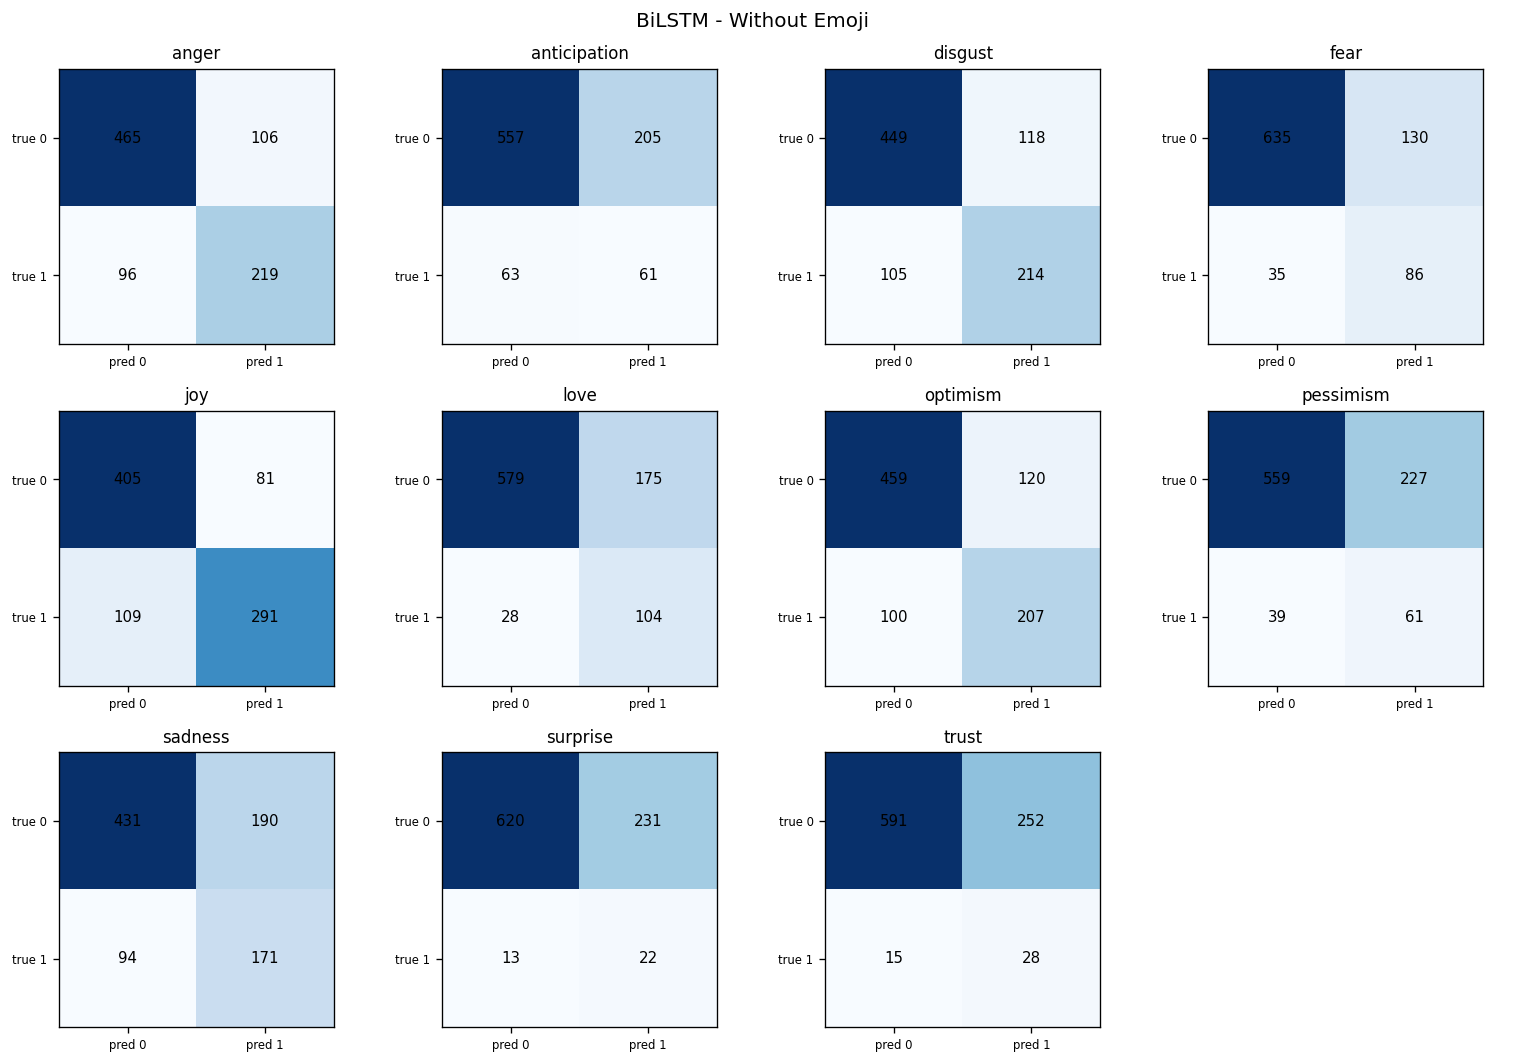

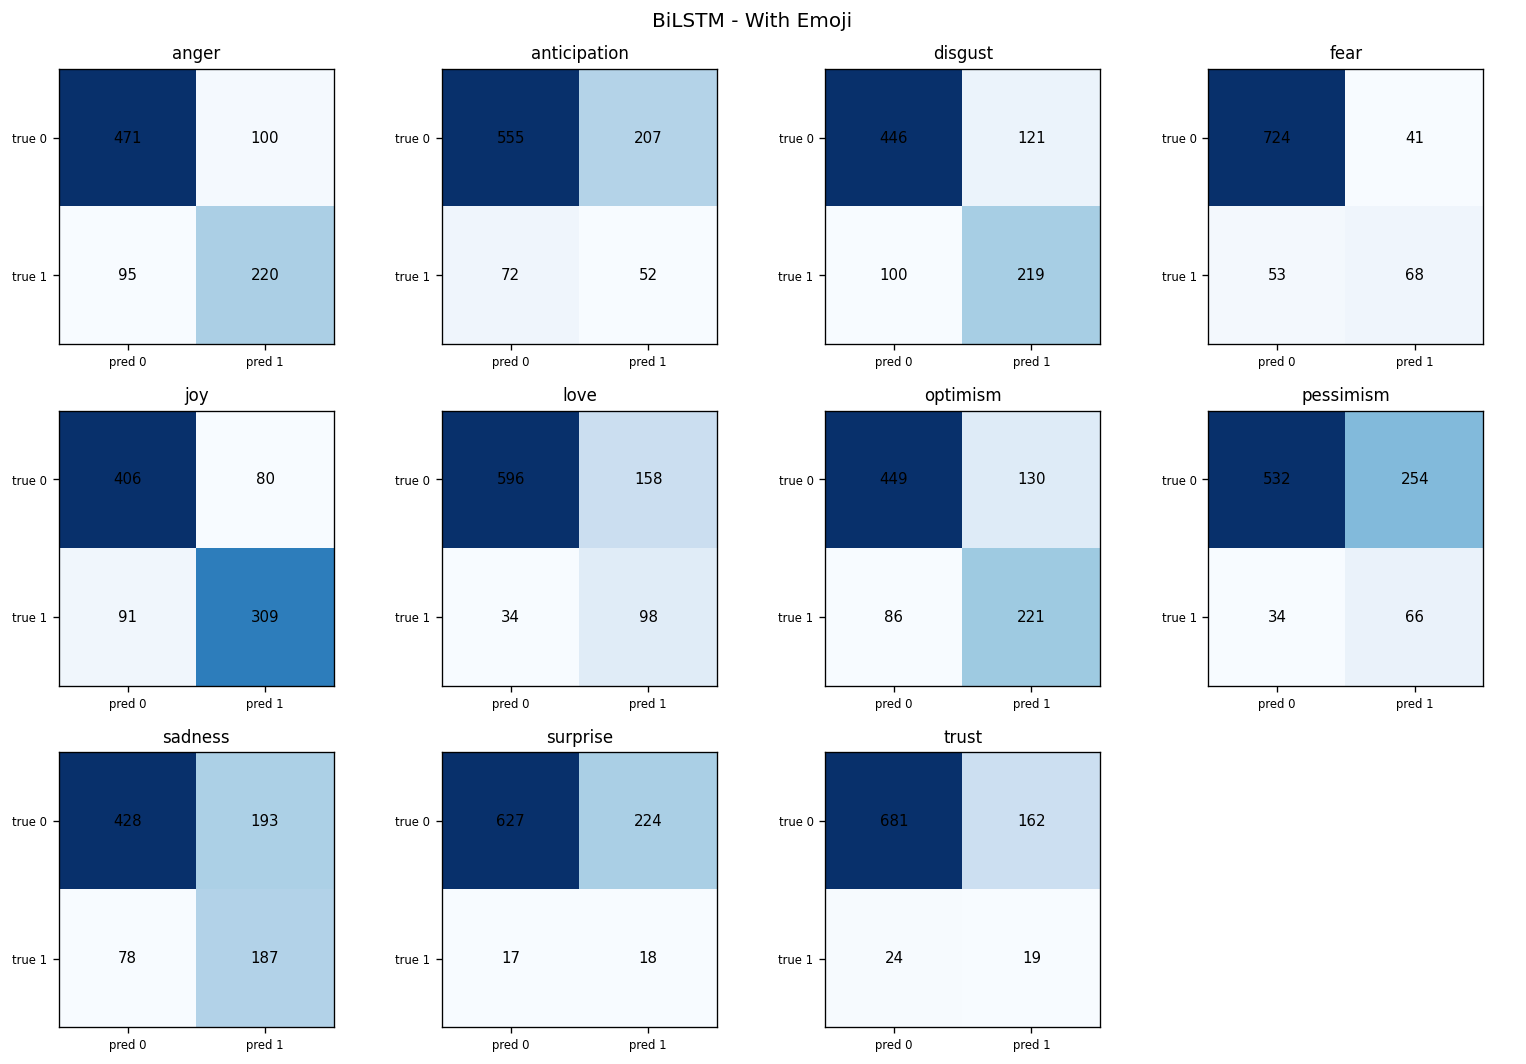

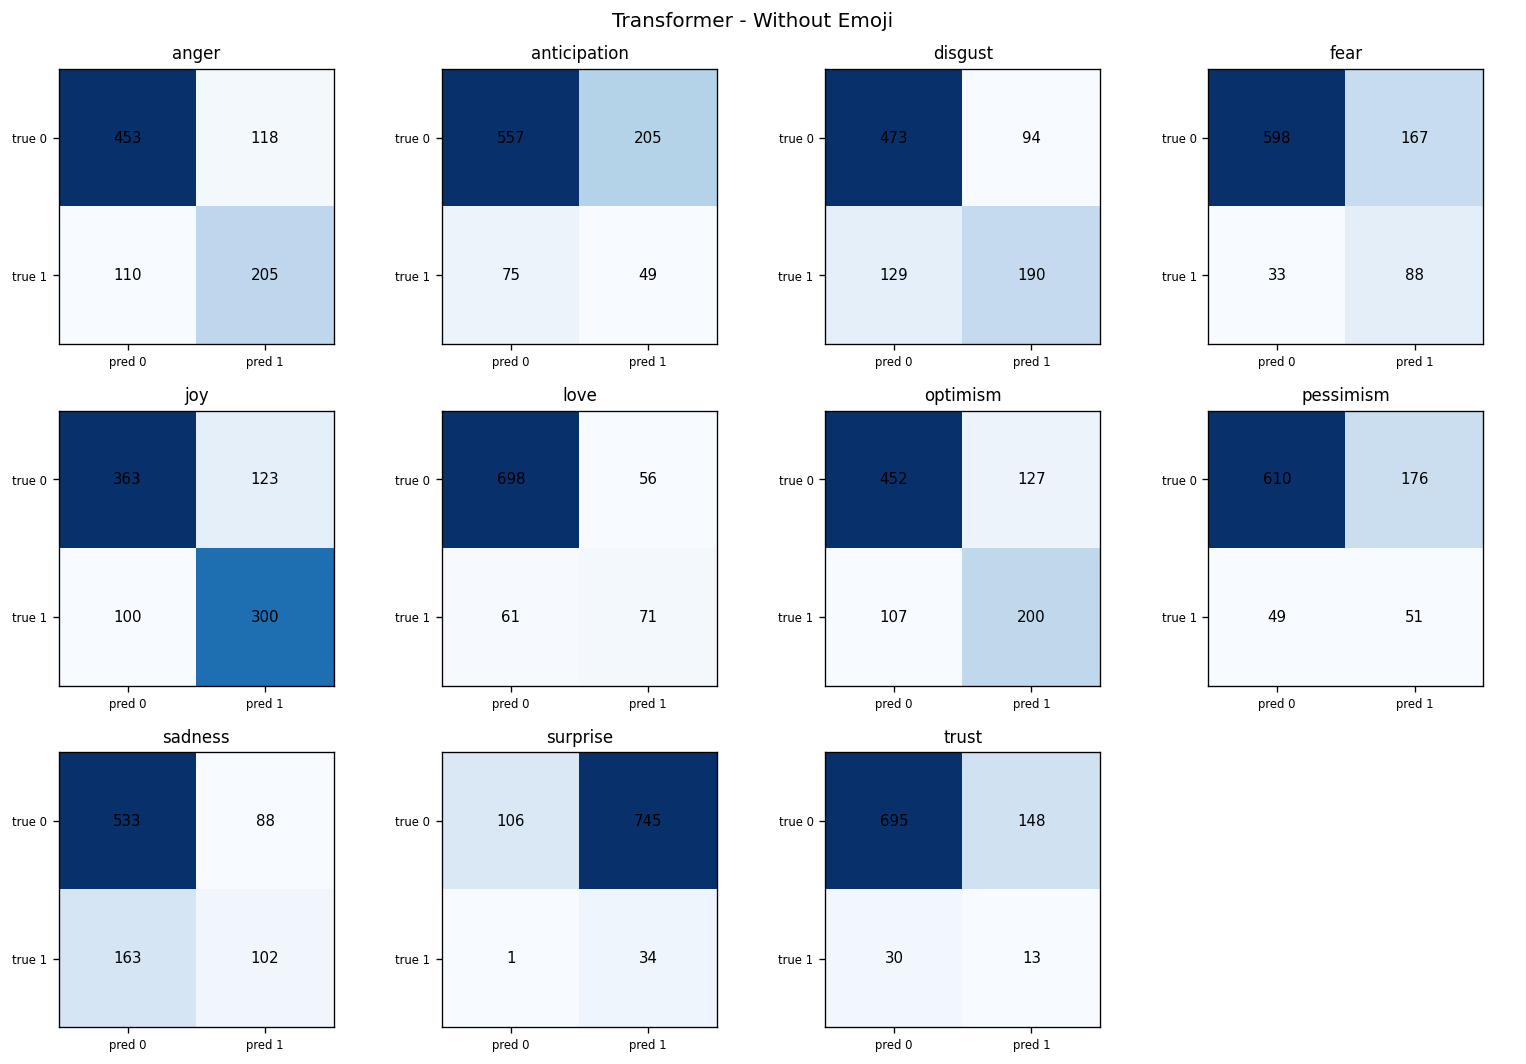

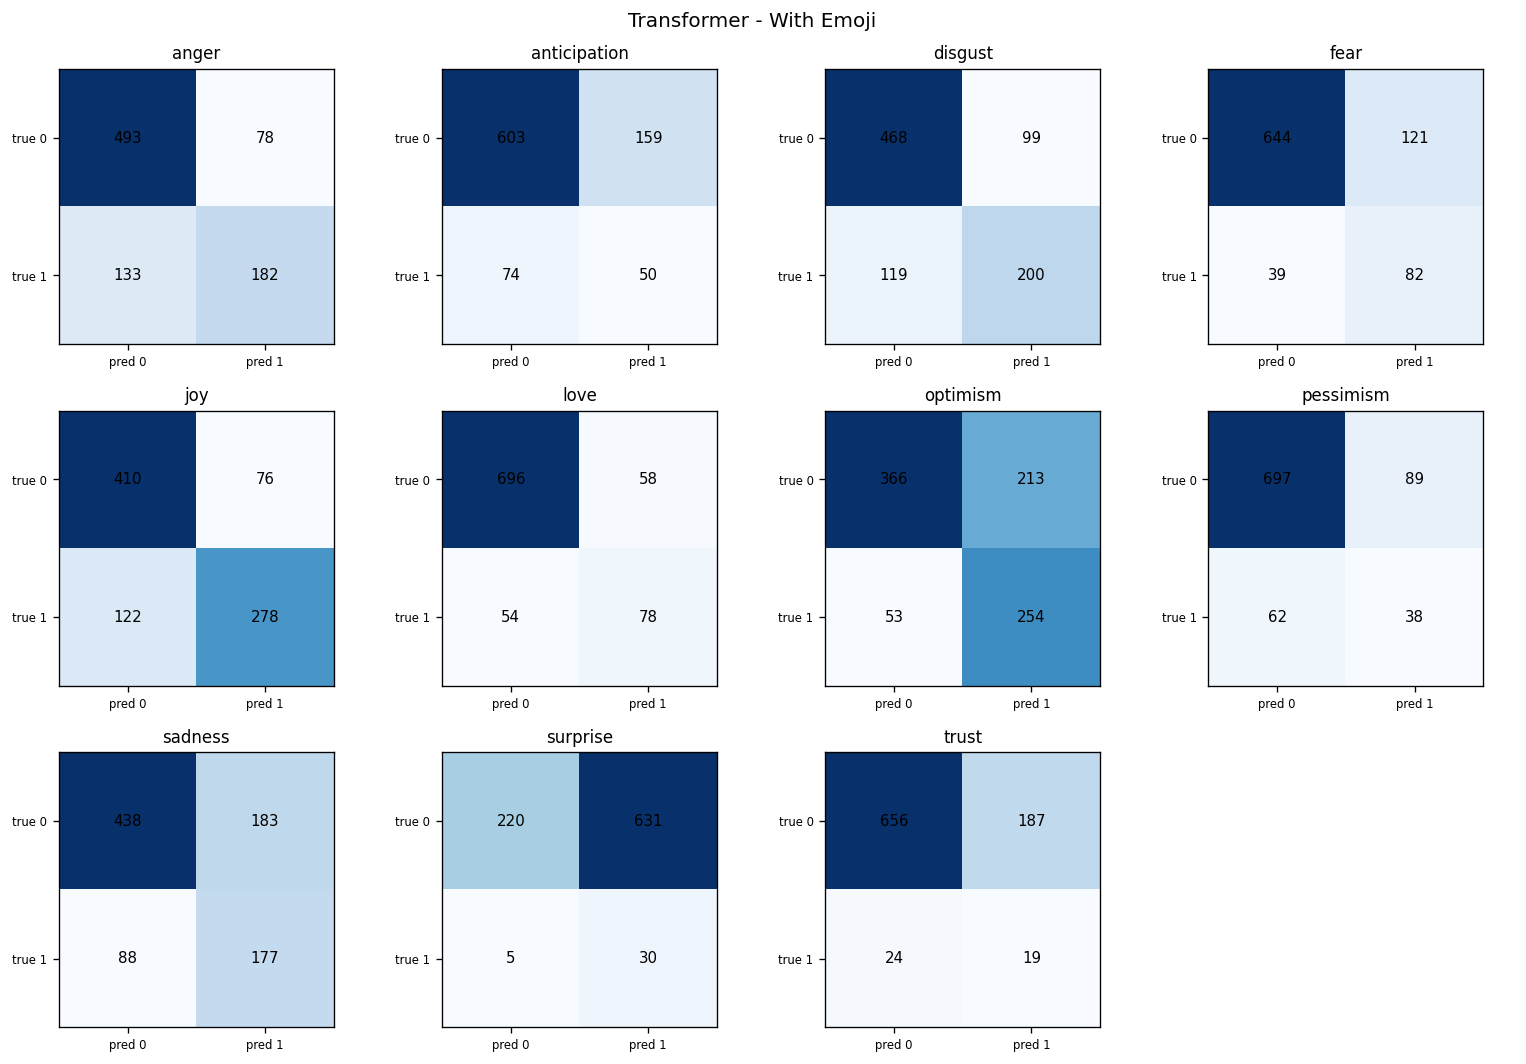

In [ ]:
cm_rows = []
for (model_key, track), y_pred in preds.items():
    fig, axes = plt.subplots(3, 4, figsize=(13, 9))
    for i, emo in enumerate(EMOTION_LABELS):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        cm_rows.append({"model": MODEL_LABEL[model_key], "track": TRACK_LABEL[track],
                        "emotion": emo, "TP": tp, "FP": fp, "FN": fn, "TN": tn})
        ax = axes.flatten()[i]
        ax.imshow(cm, cmap="Blues")
        ax.set_title(emo, fontsize=10)
        ax.set_xticks([0, 1], ["pred 0", "pred 1"], fontsize=7)
        ax.set_yticks([0, 1], ["true 0", "true 1"], fontsize=7)
        for r in range(2):
            for cc in range(2):
                ax.text(cc, r, cm[r, cc], ha="center", va="center", fontsize=9)
    axes.flatten()[-1].axis("off")
    fig.suptitle(f"{MODEL_LABEL[model_key]} - {TRACK_LABEL[track]}")
    plt.tight_layout()
    plt.savefig(FIGURES / f"confusion_{model_key.lower()}_{track}.png")
    plt.show()

confusion_counts = pd.DataFrame(cm_rows)
confusion_counts.to_csv(RESULTS / "confusion_counts.csv", index=False)

In [ ]:
# Where is the model firing far more often than the label actually occurs?
over = (confusion_counts.assign(ratio=lambda d: d["FP"] / d["TP"].clip(lower=1))
        .sort_values("ratio", ascending=False).head(8))
print("Most over-predicted (false positives per true positive):")
display(over[["model", "track", "emotion", "TP", "FP", "FN", "ratio"]].round(1))

Most over-predicted (false positives per true positive):


,model,track,emotion,TP,FP,FN,ratio
31,Transformer,Without Emoji,surprise,34,745,1,21.9
42,Transformer,With Emoji,surprise,30,631,5,21.0
20,BiLSTM,With Emoji,surprise,18,224,17,12.4
32,Transformer,Without Emoji,trust,13,148,30,11.4
9,BiLSTM,Without Emoji,surprise,22,231,13,10.5
43,Transformer,With Emoji,trust,19,187,24,9.8
10,BiLSTM,Without Emoji,trust,28,252,15,9.0
21,BiLSTM,With Emoji,trust,19,162,24,8.5


## 4.6 ROC-AUC — a threshold-free check

Every metric so far depends on the tuned threshold. AUC does not: it measures
whether the model *ranks* positives above negatives at all. If ΔF1 and ΔAUC point
the same way, the emoji effect is a real change in the learned representation
rather than an artefact of where the cut was placed.

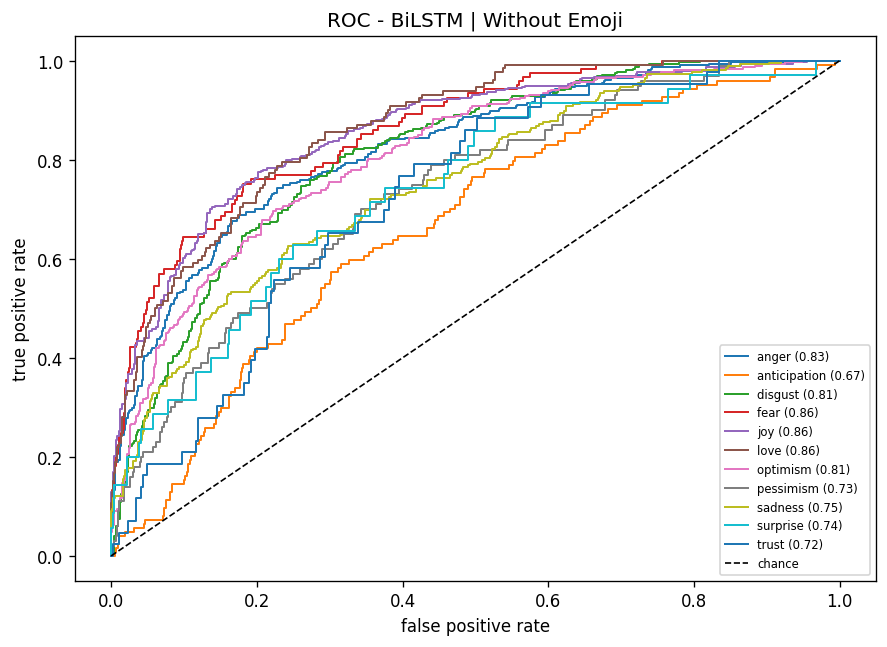

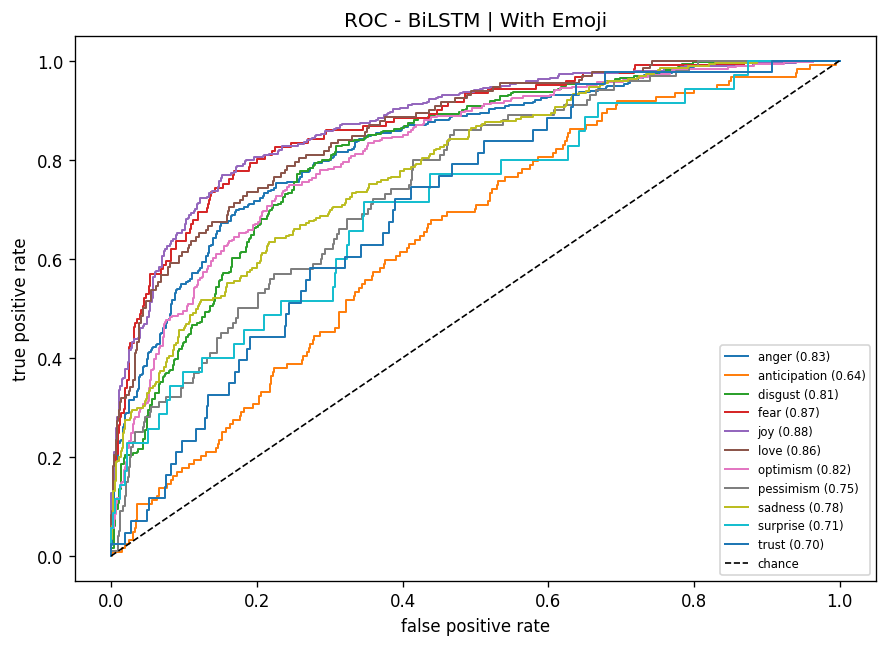

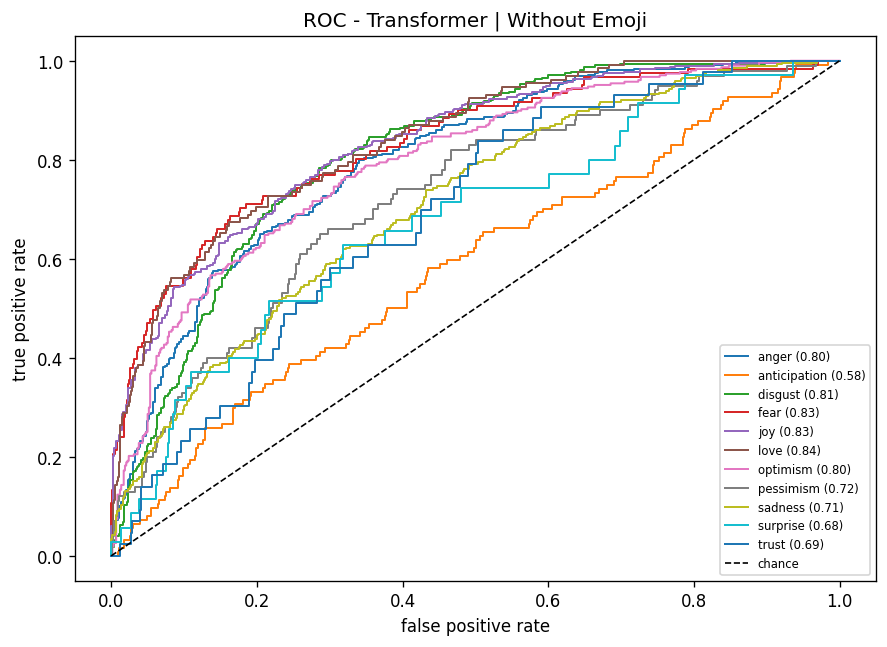

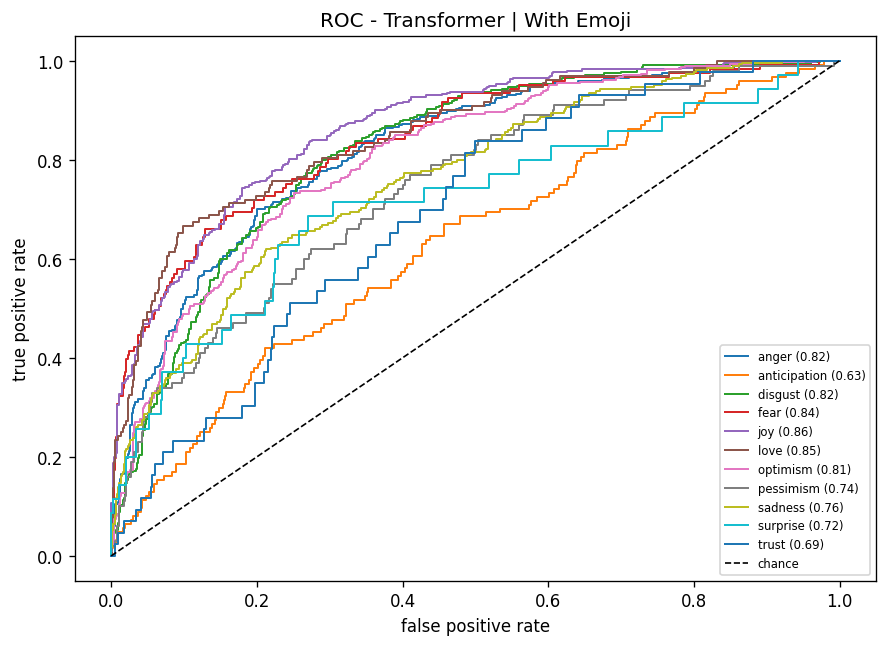

,model,track,mean AUC
0,BiLSTM,With Emoji,0.788
1,BiLSTM,Without Emoji,0.786
2,Transformer,With Emoji,0.777
3,Transformer,Without Emoji,0.754


In [ ]:
auc_rows = []
for (model_key, track), p in probs.items():
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for i, emo in enumerate(EMOTION_LABELS):
        if len(np.unique(y_true[:, i])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true[:, i], p[:, i])
        a = auc(fpr, tpr)
        auc_rows.append({"model": MODEL_LABEL[model_key], "track": TRACK_LABEL[track],
                         "emotion": emo, "auc": round(a, 3)})
        ax.plot(fpr, tpr, lw=1.2, label=f"{emo} ({a:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
    ax.set_xlabel("false positive rate")
    ax.set_ylabel("true positive rate")
    ax.set_title(f"ROC - {MODEL_LABEL[model_key]} | {TRACK_LABEL[track]}")
    ax.legend(fontsize=7, loc="lower right")
    plt.tight_layout()
    plt.savefig(FIGURES / f"roc_{model_key.lower()}_{track}.png")
    plt.show()

auc_df = pd.DataFrame(auc_rows)
auc_df.to_csv(RESULTS / "per_emotion_auc.csv", index=False)

mean_auc = (auc_df.groupby(["model", "track"])["auc"].mean().round(3)
            .reset_index().rename(columns={"auc": "mean AUC"}))
mean_auc.to_csv(RESULTS / "mean_auc.csv", index=False)
display(mean_auc)

In [ ]:
print("Does AUC agree with F1 on the direction of the emoji effect?\n")
for model_key in ("LSTM", "BERT"):
    name = MODEL_LABEL[model_key]
    a = mean_auc.loc[(mean_auc.model == name) & (mean_auc.track == "Without Emoji"),
                     "mean AUC"].iloc[0]
    b = mean_auc.loc[(mean_auc.model == name) & (mean_auc.track == "With Emoji"),
                     "mean AUC"].iloc[0]
    d_auc = b - a
    d_f1 = emoji_impact.loc[emoji_impact.Model == name, "d_micro_f1"].iloc[0]
    agree = "AGREE" if np.sign(d_auc) == np.sign(d_f1) else "DISAGREE"
    print(f"  {name:12s} dAUC {d_auc:+.3f} | dMicro-F1 {d_f1:+.2f}  -> {agree}")

Does AUC agree with F1 on the direction of the emoji effect?

  BiLSTM       dAUC +0.002 | dMicro-F1 +2.03  -> AGREE
  Transformer  dAUC +0.023 | dMicro-F1 +3.71  -> AGREE


## 4.7 The precision-recall trade-off

The weighted loss and low thresholds deliberately push the models to predict
positives liberally. That is the right trade for screening or exploratory use and
the wrong one where each positive prediction triggers a costly action, so it should
be stated rather than left implicit.

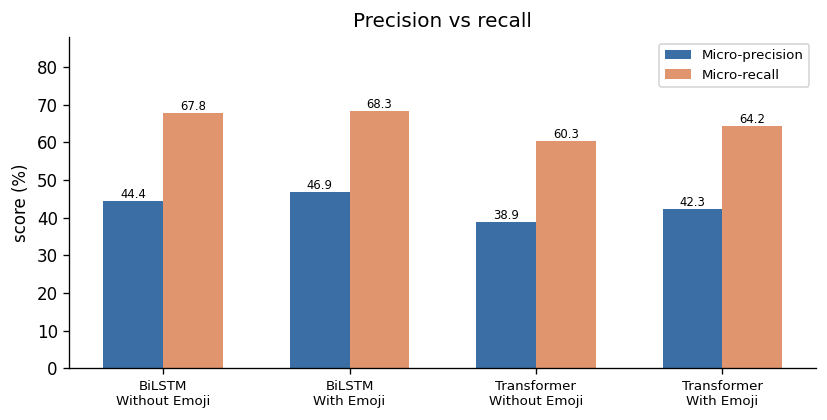

recall exceeds precision by 21.4 to 23.4 points in every condition


In [ ]:
x = np.arange(len(results_table))
w = 0.32
fig, ax = plt.subplots(figsize=(7, 3.6))
b1 = ax.bar(x - w / 2, results_table["Precision"], w, label="Micro-precision", color=BLUE)
b2 = ax.bar(x + w / 2, results_table["Recall"], w, label="Micro-recall", color="#E0956F")
ax.bar_label(b1, fmt="%.1f", fontsize=7)
ax.bar_label(b2, fmt="%.1f", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([f"{r.Model}\n{r.Track}" for r in results_table.itertuples()],
                   fontsize=8)
ax.set_ylabel("score (%)")
ax.set_ylim(0, 88)
ax.legend(fontsize=8)
ax.set_title("Precision vs recall")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "precision_recall.png")
plt.show()

margin = (results_table["Recall"] - results_table["Precision"])
print(f"recall exceeds precision by {margin.min():.1f} to {margin.max():.1f} points "
      "in every condition")

## 4.8 How much weight will these numbers bear?

A performance analysis that omits this question is incomplete. Three limits apply,
and they are the reason the conclusions are stated conditionally.

In [ ]:
search_log = pd.read_csv(RESULTS / "hyperparameter_search.csv")
spread = search_log["micro_f1"].max() - search_log["micro_f1"].min()
max_effect = emoji_impact["d_micro_f1"].abs().max()

print(f"1. Spread across hyper-parameter configurations : {spread:.2f} points")
print(f"   Largest emoji effect measured               : {max_effect:.2f} points")
if max_effect < spread:
    print("   -> the effect is SMALLER than configuration-driven variation.")
    print("      Each condition was trained once with a single seed, so no estimate")
    print("      of run-to-run variance exists. The aggregate result is indicative,")
    print("      not confirmed. The per-emotion effects are far larger and safer.\n")

print("2. Model selection, threshold selection and reporting all used the SAME")
print("   development split, so absolute values are optimistic. The bias applies")
print("   equally to both tracks, so the comparison between them still holds.\n")

print("3. Only a minority of tweets contain emoji (see notebook 02), so the")
print("   aggregate effect is diluted by rows the manipulation cannot touch.")

1. Spread across hyper-parameter configurations : 7.38 points
   Largest emoji effect measured               : 3.71 points
   -> the effect is SMALLER than configuration-driven variation.
      Each condition was trained once with a single seed, so no estimate
      of run-to-run variance exists. The aggregate result is indicative,
      not confirmed. The per-emotion effects are far larger and safer.

2. Model selection, threshold selection and reporting all used the SAME
   development split, so absolute values are optimistic. The bias applies
   equally to both tracks, so the comparison between them still holds.

3. Only a minority of tweets contain emoji (see notebook 02), so the
   aggregate effect is diluted by rows the manipulation cannot touch.


## 4.9 Optional — the held-out test split

The test split was preserved unused so that it remains a genuine holdout. Running
it converts the indicative development results into confirmatory ones, and needs
no retraining.

**Set the flag below to `True` only when you are ready to report the outcome.**
Once consumed, it is no longer an untouched holdout.

In [ ]:
RUN_TEST_EVALUATION = False   # <- set True to consume the holdout

if not RUN_TEST_EVALUATION:
    print("Skipped. The test split remains untouched.")
else:
    test = pd.read_csv(PROCESSED / "test_cleaned.csv")
    y_test = test[EMOTION_LABELS].values.astype(int)
    rows = []
    for model_key in ("LSTM", "BERT"):
        for track, text_col, _ in TRACKS:
            model = tf.keras.models.load_model(
                str(MODELS / f"{model_key.lower()}_{track}.keras"), compile=False)
            p = tf.nn.sigmoid(model.predict(
                tf.constant(test[text_col].astype(str).tolist(), dtype=tf.string),
                batch_size=64, verbose=0)).numpy()
            # thresholds stay fixed from the development split - not re-tuned here
            yp = (p >= thresholds[f"{model_key}_{track}"]).astype(int)
            rows.append({"Model": MODEL_LABEL[model_key], "Track": TRACK_LABEL[track],
                         "Micro F1": round(f1_score(y_test, yp, average="micro", zero_division=0) * 100, 2),
                         "Macro F1": round(f1_score(y_test, yp, average="macro", zero_division=0) * 100, 2)})
    test_table = pd.DataFrame(rows)
    test_table.to_csv(RESULTS / "test_results_table.csv", index=False)
    display(test_table)
    print("\nCompare against results_table.csv. A drop is expected and healthy:")
    print("the development figures were optimistic by construction.")

Skipped. The test split remains untouched.


## Answers to the research questions

Read the printed output above and complete these two statements.

**RQ1 — to what extent does emoji handling affect performance?**
The aggregate effect is given by `results/emoji_impact.csv`. Judge it against the
configuration spread reported in 4.8: if the effect is smaller than that spread,
it is indicative rather than confirmed.

**RQ2 — does the effect depend on architecture and emotion?**
Compare the sign of ΔMicro-F1 across the two architectures (4.3) and the range of
per-emotion effects (4.4). Opposite signs, or a per-emotion spread an order of
magnitude larger than the aggregate, both point to the same conclusion: emoji
handling is a **model-dependent and label-dependent** decision, and should be
validated on the target task rather than applied as a preprocessing default.

### Artefacts written

`results/` — results_table, emoji_impact, per_emotion_impact, per_emotion_auc,
mean_auc, confusion_counts (+ test_results_table if enabled)

`figures/` — overall_performance, emoji_impact, per_emotion_impact,
precision_recall, 4 × confusion_*, 4 × roc_*